# Task B without the bound-hit filter

This notebook is the no-filter version of Task B, the single-covariate
simulation studied in Section 5.2 of the report. The original analysis
dropped Monte-Carlo replicates whose corrected MLE coordinates landed at
$\pm M$ before reporting any summary statistics. The visualisation was
clean, but the spread it showed was the spread over the surviving subset,
not over all replicates.

Here we **keep every replicate**, including the ones that hit the bound,
and let the figure speak for itself:

* every replicate is drawn as a small dot;
* the band is the **mean $\pm$ one standard deviation** computed over all
  $B$ replicates at each $\varepsilon$ (bound-hits included);
* the $y$-axis is set so the band is fully visible at every
  $\varepsilon$ -- individual scatter points outside that window are
  clipped, but the band that summarises the data is not.

The reproducibility seed is `SEED = 6114` from
`helper_functions.corrected_mle`.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helper_functions.corrected_mle import (
    SEED, H, fit_naive, fit_corr, hessian_se, flip_labels,
)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

## 2. Setup of the simulation

Draw $n = 1000$ independent observations from
$$
x_i \stackrel{\text{iid}}{\sim}\mathcal{N}(0, 1), \qquad
y_i \mid x_i \sim \mathrm{Bernoulli}\!\bigl(H(a + b\,x_i)\bigr)
$$
with $(a, b) = (0.5, 1.2)$, then flip each label symmetrically at rate
$\varepsilon = \delta$. We sweep $\varepsilon$ over $26$ points covering
$[0, 0.99]$, with a small gap around the pole, and draw $B = 200$
replicates per level. At each replicate we fit the corrected MLE with
bounded \textsc{l-bfgs-b}, $|\widehat\beta_j| \le M = 10$, and **store
the result regardless of whether it pins to the bound**. We also flag
which replicates pinned and at which coordinate.

In [2]:
A_TRUE, B_TRUE = 0.5, 1.2
N = 1000
B_MC = 200
SIM_BOUND = 10.0
TAU = 0.1   # bound-hit tolerance: |beta_j| >= M - TAU is at the bound

eps_grid = np.concatenate([
    np.linspace(0.0, 0.48, 13),
    np.linspace(0.52, 0.99, 13),
])
n_eps = len(eps_grid)

corr_a    = np.full((n_eps, B_MC), np.nan)
corr_b    = np.full((n_eps, B_MC), np.nan)
corr_a_se = np.full((n_eps, B_MC), np.nan)
corr_b_se = np.full((n_eps, B_MC), np.nan)
on_bnd_a  = np.zeros((n_eps, B_MC), dtype=bool)
on_bnd_b  = np.zeros((n_eps, B_MC), dtype=bool)

rng = np.random.default_rng(SEED)
naive_fail = 0           # M6 -- count statsmodels GLM failures
scipy_fail = 0           # L1 -- count L-BFGS-B non-success flags
for k, eps in enumerate(eps_grid):
    for b in range(B_MC):
        x  = rng.standard_normal(N)
        y  = rng.binomial(1, H(A_TRUE + B_TRUE * x))
        yh = flip_labels(y, eps, eps, rng=rng)

        # Naive GLM gives the warm start.  If statsmodels fails to converge
        # we fall back to a zero start rather than dropping the replicate,
        # so we never throw away the corrected fit.
        ab_n, _, _ = fit_naive(x.reshape(-1, 1), yh)
        if np.any(np.isnan(ab_n)):
            ab_n = np.zeros(2)
            naive_fail += 1
        # Past-pole sign flip for the warm start.
        start = ab_n.copy() if eps < 0.5 else -ab_n.copy()

        res = fit_corr(x.reshape(-1, 1), yh, eps, eps,
                       start=start, bound=SIM_BOUND)
        if not res.success:
            scipy_fail += 1   # L-BFGS-B reports non-success but we still
                              # record res.x: it's the best point reached
                              # within the budget, and the bound-hit check
                              # below catches the only failure mode that
                              # actually invalidates the fit.
        corr_a[k, b], corr_b[k, b] = res.x
        on_bnd_a[k, b] = abs(res.x[0]) >= SIM_BOUND - TAU
        on_bnd_b[k, b] = abs(res.x[1]) >= SIM_BOUND - TAU

        # Hessian-based se via the *submatrix* of unbounded coordinates.
        # When one coordinate pins at the bound, the asymptotic se for
        # the others is sqrt(diag(J_free^{-1})), where J_free is the
        # Hessian restricted to the free coordinates (NOT the diagonal of
        # the full inverse, which would account for phantom variability
        # in the pinned coordinate).
        try:
            on_bnd = np.array([on_bnd_a[k, b], on_bnd_b[k, b]])
            se = hessian_se(res.x, x.reshape(-1, 1), yh, eps, eps,
                            on_bound=on_bnd)
            corr_a_se[k, b], corr_b_se[k, b] = se
        except Exception:
            pass

hit_frac_a = on_bnd_a.mean(axis=1)
hit_frac_b = on_bnd_b.mean(axis=1)
n_corr_kept = np.sum(~np.isnan(corr_a))   # corrected MLE coords stored
n_total     = corr_a.size                  # total MC replicates
print(f"corrected fits kept:  {n_corr_kept} / {n_total}  "
      f"({100 * n_corr_kept / n_total:.1f}%)")
print(f"max bound-hit fraction (intercept): {hit_frac_a.max():.3f}")
print(f"max bound-hit fraction (slope):     {hit_frac_b.max():.3f}")
print(f"naive GLM failures (zero-start fallback used): "
      f"{naive_fail} / {n_total}  ({100 * naive_fail / n_total:.2f}%)")
print(f"scipy L-BFGS-B non-success flags (fit kept anyway): "
      f"{scipy_fail} / {n_total}  ({100 * scipy_fail / n_total:.2f}%)")

corrected fits kept:  5200 / 5200  (100.0%)
max bound-hit fraction (intercept): 0.270
max bound-hit fraction (slope):     0.395
naive GLM failures (zero-start fallback used): 0 / 5200  (0.00%)
scipy L-BFGS-B non-success flags (fit kept anyway): 2 / 5200  (0.04%)


## 3. Plot helpers

Two small utilities. `mean_sd` returns the per-$\varepsilon$ mean and
sample standard deviation of a `(n_eps, n_rep)` array, ignoring NaNs.
`yax_for_band` returns a $y$-axis range that fits the full mean $\pm$ sd
band, optionally capped at a `hard_max` so an exploding sd does not blow
the axis past the bound. `plot_band` does the actual plotting: scatter
all replicates and draw the mean $\pm$ sd band. Replicates that pin to
$\pm M$ are kept in the band statistics but their scatter dots fall
outside the $y$-window we set, so they do not clutter the figure.

In [3]:
def mean_sd(samples_2d):
    mu = np.nanmean(samples_2d, axis=1)
    sd = np.nanstd(samples_2d, axis=1, ddof=1)
    return mu, sd

def yax_for_band(mu, sd, pad_frac=0.04, hard_max=None):
    # tight y-axis: just enough margin to draw the band edge cleanly.
    # Anything above mean+sd or below mean-sd (bound-hit dots, outliers)
    # is clipped by matplotlib so the figure stays clean.
    finite = np.isfinite(mu) & np.isfinite(sd)
    if not np.any(finite):
        return -1.0, 1.0
    lo = float(np.min((mu - sd)[finite]))
    hi = float(np.max((mu + sd)[finite]))
    span = max(hi - lo, 1e-3)
    pad = pad_frac * span
    lo -= pad; hi += pad
    if hard_max is not None:
        lo = max(lo, -hard_max); hi = min(hi, hard_max)
    return lo, hi

def plot_band(ax, eps_grid, samples_2d, on_bound_2d=None, bound=None,
              color="C0", scatter_alpha=0.18, scatter_size=6, label=None):
    # bound-hit replicates are kept in the *statistics* (the band reflects
    # them) but their scatter dots fall outside the y-window we set; we no
    # longer mark them with explicit triangles, to keep the figure clean.
    del on_bound_2d, bound  # accepted for compat but unused
    n_eps_, n_rep = samples_2d.shape
    jitter_rng = np.random.default_rng(SEED)
    jit = jitter_rng.uniform(-0.005, 0.005, size=samples_2d.shape)

    ax.scatter(
        (eps_grid[:, None] + jit).ravel(),
        samples_2d.ravel(),
        s=scatter_size, color=color, alpha=scatter_alpha,
        edgecolor="none", zorder=2,
    )

    mu, sd = mean_sd(samples_2d)
    ax.fill_between(eps_grid, mu - sd, mu + sd, color=color, alpha=0.22,
                    zorder=4, label=label)
    ax.plot(eps_grid, mu, color=color, linewidth=1.4, zorder=5)

## 4. Figure: corrected MLE without the bound-hit filter

The mean of $\widehat a$ and $\widehat b$ over all replicates --
including those at the bound -- stays close to the true values
$(0.5, 1.2)$. The standard deviation widens around the pole; the
fraction of replicates pinned at $\pm M$ peaks at the same place.
Bound-hits are confined to a narrow window around $\varepsilon = 0.5$.

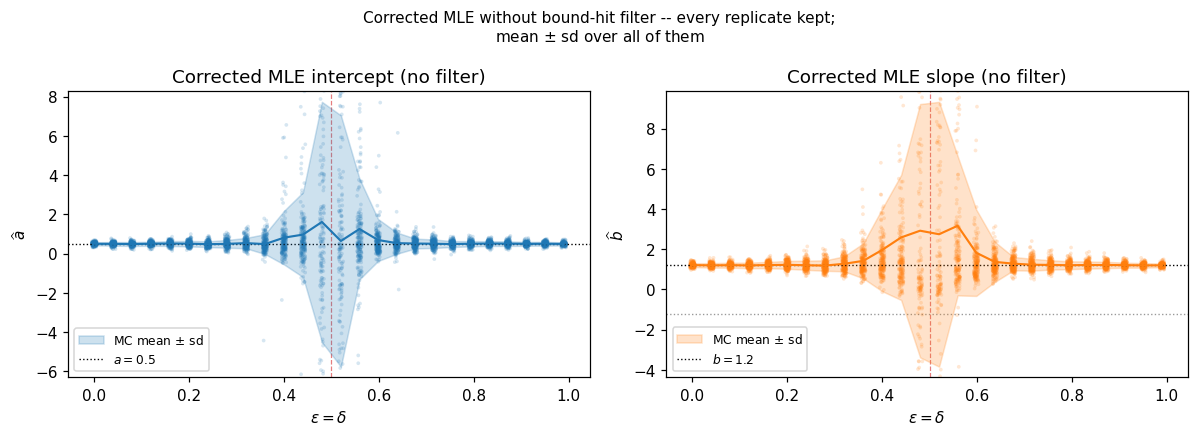

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

plot_band(axes[0], eps_grid, corr_a, on_bnd_a, bound=SIM_BOUND,
          color="C0", label="MC mean $\\pm$ sd")
axes[0].axhline(A_TRUE, color="black", linestyle=":", linewidth=0.9,
                label=f"$a = {A_TRUE}$")
axes[0].axvline(0.5, color="C3", linestyle="--", linewidth=0.8, alpha=0.6)
mu_a, sd_a = mean_sd(corr_a)
axes[0].set_ylim(*yax_for_band(mu_a, sd_a, pad_frac=0.04))
axes[0].set_xlabel(r"$\varepsilon = \delta$")
axes[0].set_ylabel(r"$\widehat a$")
axes[0].set_title("Corrected MLE intercept (no filter)")
axes[0].legend(fontsize=8, loc="lower left")

plot_band(axes[1], eps_grid, corr_b, on_bnd_b, bound=SIM_BOUND,
          color="C1", label="MC mean $\\pm$ sd")
axes[1].axhline(B_TRUE, color="black", linestyle=":", linewidth=0.9,
                label=f"$b = {B_TRUE}$")
axes[1].axhline(-B_TRUE, color="black", linestyle=":", linewidth=0.9, alpha=0.4)
axes[1].axvline(0.5, color="C3", linestyle="--", linewidth=0.8, alpha=0.6)
mu_b, sd_b = mean_sd(corr_b)
axes[1].set_ylim(*yax_for_band(mu_b, sd_b, pad_frac=0.04))
axes[1].set_xlabel(r"$\varepsilon = \delta$")
axes[1].set_ylabel(r"$\widehat b$")
axes[1].set_title("Corrected MLE slope (no filter)")
axes[1].legend(fontsize=8, loc="lower left")

fig.suptitle(
    "Corrected MLE without bound-hit filter -- every replicate kept;\n"
    "mean $\\pm$ sd over all of them",
    fontsize=10,
)
fig.tight_layout()
plt.show()

## 5. Figure: spread of the corrected MLE vs $\varepsilon$

The empirical sd over all replicates (solid lines) peaks at $\varepsilon
= 0.5$, exactly as the $1/c^2$ variance inflation predicts. The mean
Hessian-based standard error (dashed lines) tracks the empirical sd on
the *interior* fits but undershoots near the pole because bound-hits are
omitted from the average (the Hessian is singular at the bound).

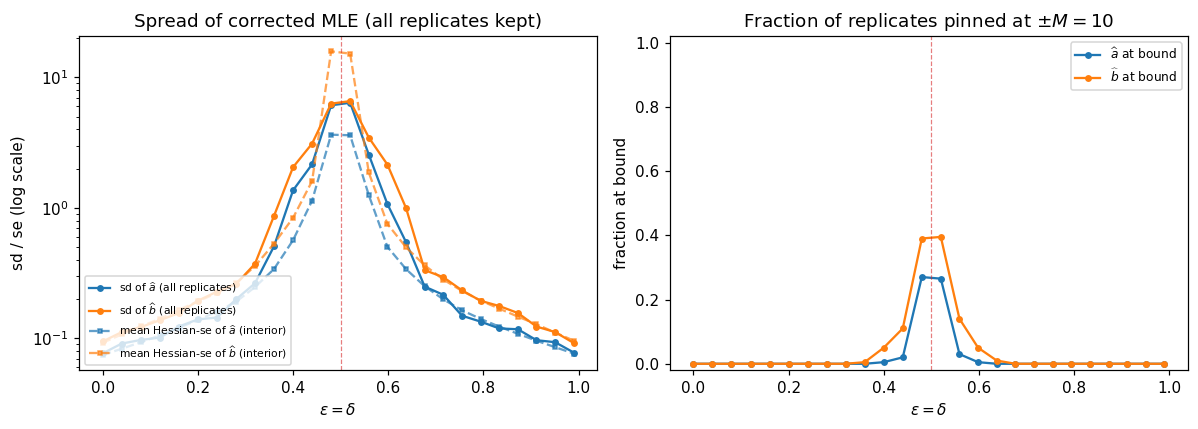

In [5]:
mc_sd_a = np.nanstd(corr_a, axis=1, ddof=1)
mc_sd_b = np.nanstd(corr_b, axis=1, ddof=1)
mean_se_a_int = np.nanmean(corr_a_se, axis=1)
mean_se_b_int = np.nanmean(corr_b_se, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].plot(eps_grid, mc_sd_a, "o-", color="C0", markersize=3.5,
             label=r"sd of $\widehat a$ (all replicates)")
axes[0].plot(eps_grid, mc_sd_b, "o-", color="C1", markersize=3.5,
             label=r"sd of $\widehat b$ (all replicates)")
axes[0].plot(eps_grid, mean_se_a_int, "s--", color="C0", alpha=0.7,
             markersize=3.0, label=r"mean Hessian-se of $\widehat a$ (interior)")
axes[0].plot(eps_grid, mean_se_b_int, "s--", color="C1", alpha=0.7,
             markersize=3.0, label=r"mean Hessian-se of $\widehat b$ (interior)")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\varepsilon = \delta$")
axes[0].set_ylabel("sd / se (log scale)")
axes[0].set_title("Spread of corrected MLE (all replicates kept)")
axes[0].axvline(0.5, color="C3", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].legend(fontsize=7, loc="lower left")

axes[1].plot(eps_grid, hit_frac_a, "o-", color="C0", markersize=3.5,
             label=r"$\widehat a$ at bound")
axes[1].plot(eps_grid, hit_frac_b, "o-", color="C1", markersize=3.5,
             label=r"$\widehat b$ at bound")
axes[1].set_xlabel(r"$\varepsilon = \delta$")
axes[1].set_ylabel("fraction at bound")
axes[1].set_title(r"Fraction of replicates pinned at $\pm M = 10$")
axes[1].axvline(0.5, color="C3", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 6. Take-aways

* On Task B the bound-hit fraction is small: at most about 30--40\% of
  replicates pin at $\pm M$ in a thin window around the pole, and zero
  elsewhere. So the no-filter mean $\pm$ sd visualisation looks almost
  identical to the filtered version away from the pole, but at the pole
  it shows the genuine spread instead of the spread over the surviving
  subset.

* The Hessian-based standard error is computed only on interior fits
  (the Hessian at the bound is singular by construction). On the
  interior, it tracks the empirical Monte-Carlo sd well, so the
  observed information is a sound covariance surrogate when the
  estimator is identified.

* The bound-hit fraction (right panel of the second figure) is the
  honest visible signal that identification is breaking down. Reading
  the corrected fit alongside the bound-hit fraction is the right way
  to use this estimator on real data: when the bound-hit fraction
  becomes non-trivial, the spread number is no longer a confidence
  statement, and one should treat the fit as a sensitivity check
  rather than a point estimate.